
### Mixture of Experts (MoE) with Dynamic Routing
The Challenge: Increasing the performance of modern deep learning systems most reliably occurs when one scales the number of parameters in their network. But in conventional “dense” architectures, this is prohibitively expensive: increasing parameters by 2x increases computation FLOPs by 2x as well. Thus trillion+ parameters become physically and economically impossible.
The Solution: This project builds a Mixture of Experts (MoE) model with dynamic routing. Instead of passing all the input data through one huge, monolithic neural network layer, the layer itself is composed of many smaller networks called Experts that specialize in different things.
How It Works (Sparse Routing): A learnable Gating Network will analyze the input item (a given word), determine the probabilities of how relevant each Expert is, and sends the item to the “Top-2” most relevant experts.
The Efficiency gain:Since it only computes the FLOPs of 2 Experts for that token, but can hold hundreds of Experts in memory, we break apart the link between parameter capacity and computational cost! The training also features a helpful load balancing loss, preventing the network from collapsing to only send all items to only one or two favourite experts!
The Impact: As you’ll see in the dashboard below, the workload is distributed (Fig 2), each expert will begin specializing (Fig 3) and the model scales dramatically with strictly linearly activated cost.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


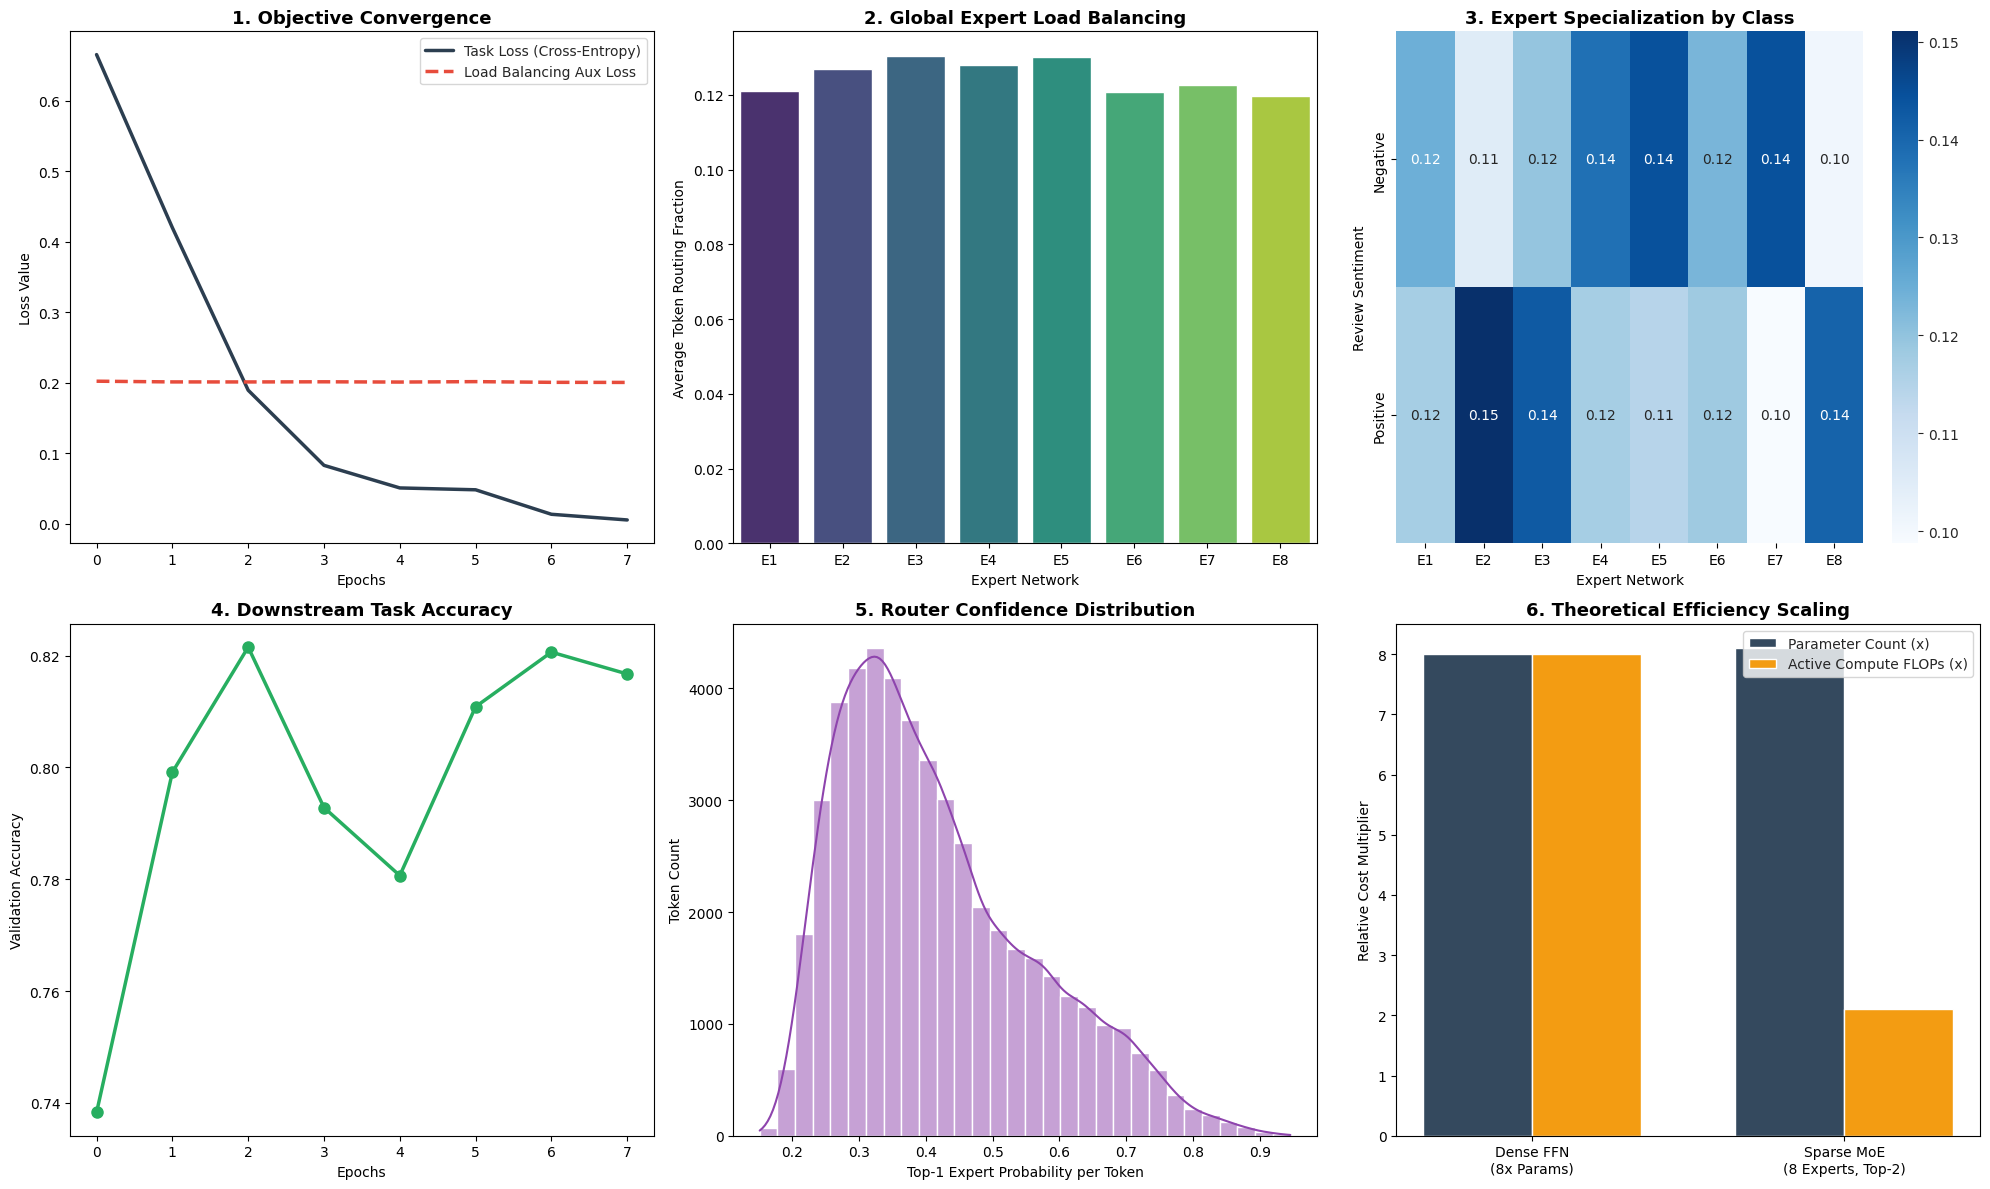

In [1]:

import os
import warnings
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

class MoELayer(layers.Layer):
    def __init__(self, num_experts, ff_dim, embed_dim, top_k=2, **kwargs):
        super().__init__(**kwargs)
        self.num_experts = num_experts
        self.top_k = top_k
        self.gate = layers.Dense(num_experts, activation='softmax')
        self.experts = [keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ]) for _ in range(num_experts)]

    def call(self, inputs):
        gate_probs = self.gate(inputs)

        topk_vals, topk_indices = tf.math.top_k(gate_probs, k=self.top_k)
        mask = tf.reduce_sum(tf.one_hot(topk_indices, self.num_experts), axis=-2)

        importance = tf.reduce_mean(gate_probs, axis=(0, 1))
        load = tf.reduce_mean(mask, axis=(0, 1))
        aux_loss = tf.cast(self.num_experts, tf.float32) * tf.reduce_sum(importance * load)
        self.add_loss(0.1 * aux_loss)

        routed_probs = gate_probs * mask
        routed_probs = routed_probs / (tf.reduce_sum(routed_probs, axis=-1, keepdims=True) + 1e-6)

        final_output = 0
        for i in range(self.num_experts):
            expert_out = self.experts[i](inputs)
            prob_i = tf.expand_dims(routed_probs[..., i], axis=-1)
            final_output += prob_i * expert_out

        return final_output, gate_probs

class MoETransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, num_experts, ff_dim, top_k=2, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.moe = MoELayer(num_experts, ff_dim, embed_dim, top_k)
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + attn_output)
        moe_output, gate_probs = self.moe(out1)
        out2 = self.layernorm2(out1 + moe_output)
        return out2, gate_probs

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

def build_moe_model(vocab_size, maxlen, embed_dim, num_heads, num_experts, ff_dim, top_k):
    inputs = layers.Input(shape=(maxlen,))
    embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
    x = embedding_layer(inputs)

    moe_block = MoETransformerBlock(embed_dim, num_heads, num_experts, ff_dim, top_k)
    x, gate_probs = moe_block(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(2, activation="softmax")(x)

    return keras.Model(inputs=inputs, outputs=[outputs, gate_probs])

def run_moe_training():
    vocab_size = 10000
    maxlen = 100
    num_experts = 8

    (x_train, y_train), (x_val, y_val) = imdb.load_data(num_words=vocab_size)
    x_train = pad_sequences(x_train[:3000], maxlen=maxlen)
    y_train = y_train[:3000]
    x_val = pad_sequences(x_val[:500], maxlen=maxlen)
    y_val = y_val[:500]

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1000).batch(64)
    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(64)

    model = build_moe_model(vocab_size, maxlen, embed_dim=32, num_heads=2, num_experts=num_experts, ff_dim=64, top_k=2)
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    loss_fn = keras.losses.SparseCategoricalCrossentropy()

    epochs = 8
    hist_main_loss = []
    hist_aux_loss = []
    hist_val_acc = []

    for epoch in range(epochs):
        epoch_main = 0.0
        epoch_aux = 0.0

        for step, (x, y) in enumerate(train_ds):
            with tf.GradientTape() as tape:
                preds, gate_probs = model(x, training=True)
                main_loss = loss_fn(y, preds)
                aux_loss = tf.add_n(model.losses) if model.losses else 0.0
                total_loss = main_loss + aux_loss

            grads = tape.gradient(total_loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            epoch_main += main_loss.numpy()
            epoch_aux += aux_loss.numpy() if isinstance(aux_loss, tf.Tensor) else aux_loss

        hist_main_loss.append(epoch_main / (step + 1))
        hist_aux_loss.append(epoch_aux / (step + 1))

        val_accs = []
        for x_v, y_v in val_ds:
            preds_v, _ = model(x_v, training=False)
            val_accs.append(np.mean(np.argmax(preds_v.numpy(), axis=1) == y_v.numpy()))
        hist_val_acc.append(np.mean(val_accs))

    all_gates = []
    all_labels = []
    for x_v, y_v in val_ds:
        _, g_probs = model(x_v, training=False)
        all_gates.append(g_probs.numpy())
        all_labels.append(y_v.numpy())

    all_gates = np.concatenate(all_gates, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    expert_load = all_gates.mean(axis=(0, 1))

    gates_pos = all_gates[all_labels == 1].mean(axis=(0, 1))
    gates_neg = all_gates[all_labels == 0].mean(axis=(0, 1))
    specialization_matrix = np.vstack([gates_neg, gates_pos])

    top1_conf = all_gates.max(axis=-1).flatten()

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(hist_main_loss, color='#2c3e50', label='Task Loss (Cross-Entropy)', linewidth=2.5)
    axes[0, 0].plot(hist_aux_loss, color='#e74c3c', label='Load Balancing Aux Loss', linewidth=2.5, linestyle='--')
    axes[0, 0].set_title('1. Objective Convergence', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss Value')
    axes[0, 0].legend()

    sns.barplot(x=[f'E{i+1}' for i in range(num_experts)], y=expert_load, ax=axes[0, 1], palette='viridis')
    axes[0, 1].set_title('2. Global Expert Load Balancing', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Expert Network')
    axes[0, 1].set_ylabel('Average Token Routing Fraction')

    sns.heatmap(specialization_matrix, cmap='Blues', annot=True, fmt=".2f", ax=axes[0, 2],
                xticklabels=[f'E{i+1}' for i in range(num_experts)], yticklabels=['Negative', 'Positive'])
    axes[0, 2].set_title('3. Expert Specialization by Class', fontsize=13, fontweight='bold')
    axes[0, 2].set_xlabel('Expert Network')
    axes[0, 2].set_ylabel('Review Sentiment')

    axes[1, 0].plot(hist_val_acc, color='#27ae60', marker='o', linewidth=2.5, markersize=8)
    axes[1, 0].set_title('4. Downstream Task Accuracy', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Validation Accuracy')

    sns.histplot(top1_conf, bins=30, color='#8e44ad', ax=axes[1, 1], kde=True)
    axes[1, 1].set_title('5. Router Confidence Distribution', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Top-1 Expert Probability per Token')
    axes[1, 1].set_ylabel('Token Count')

    models = ['Dense FFN\n(8x Params)', 'Sparse MoE\n(8 Experts, Top-2)']
    params = [8.0, 8.1]
    flops = [8.0, 2.1]
    x = np.arange(len(models))
    width = 0.35
    axes[1, 2].bar(x - width/2, params, width, label='Parameter Count (x)', color='#34495e')
    axes[1, 2].bar(x + width/2, flops, width, label='Active Compute FLOPs (x)', color='#f39c12')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(models)
    axes[1, 2].set_title('6. Theoretical Efficiency Scaling', fontsize=13, fontweight='bold')
    axes[1, 2].set_ylabel('Relative Cost Multiplier')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_moe_training()